## Import Libraries

In [4]:
import numpy as np
import pandas as pd
import os
import cv2
from pathlib import Path
import segmentation_models_pytorch as smp
import torch.nn.functional as F
from torchvision.transforms import transforms
import torch.nn as nn
import torch
import albumentations as A
import seaborn as sns
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [7]:
image = cv2.imread("../Dataset/train_images/0a4ad45a5.jpg", 1)

In [10]:
image.shape

(256, 1600, 3)

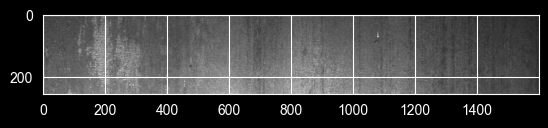

In [11]:
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.show()

In [9]:
cv2.imshow("Image", image)
cv2.waitKey(0)
cv2.destroyAllWindows()


## Data preparation

In [3]:
class DatasetBuilder:
    def __init__(self, csv_path, img_dir, original_shape=(256, 1600)):
        self.csv_path = csv_path
        self.img_dir = Path(img_dir)
        self.original_shape = original_shape

    def build_df(self):
        """
        Build a dataset from img dir for all Images:
        Args:
            img_dir: this is the path of image directory
            csv_path: this is the path of csv file( that made by run length encoding)
        return:
            dataframe: for all images
        """
        df_csv = pd.read_csv(self.csv_path)
        df_csv["HasDefect"] = df_csv["EncodedPixels"].notna()

        images_with_defect = set(df_csv['ImageId'].unique()) # use set to get unique
        print("The number of image had defect from csv:", len(images_with_defect))
        # Get all images from the folder of images
        all_images = set([image for image in os.listdir(self.img_dir) if image.endswith((".jpg", ".png", ".jpeg"))])
        print(f"The number of images from Image training: {len(all_images)}")
        images_without_defect = all_images - images_with_defect
        print(f"The number of images without defect: {len(all_images) - len(images_with_defect)}")

        # Build a dataframe for all images
        rows = []
        for _, row in df_csv.iterrows():
            rows.append(row.to_dict())
        print("Len of First update:", len(rows))

        for img_id in images_without_defect:
            for class_id in range(1, 5):
                rows.append({
                    "ImageId": img_id,
                    "ClassId": class_id,
                    "EncodedPixels": '', # Don't have defect = empty
                    "HasDefect": False
                })

        df_complete = pd.DataFrame(rows)

        print(f"\n Class distribution:")
        for cls in range(1, 5):
            cls_data = df_complete[df_complete['ClassId'] == cls]
            defect_count = cls_data['HasDefect'].sum()
            total_count = len(cls_data)
            pct = (defect_count / total_count) * 100
            print(f"   Class {cls}: {int(defect_count):5} defects / {total_count:5} total ({pct:5.1f}%)")

        return df_complete

In [4]:
csv_path = "../Dataset/train.csv"
img_dir = "../Dataset/train_images"
df_complete = DatasetBuilder(csv_path=csv_path, img_dir=img_dir).build_df()


The number of image had defect from csv: 6666
The number of images from Image training: 12568
The number of images without defect: 5902
Len of First update: 7095

 Class distribution:
   Class 1:   897 defects /  6799 total ( 13.2%)
   Class 2:   247 defects /  6149 total (  4.0%)
   Class 3:  5150 defects / 11052 total ( 46.6%)
   Class 4:   801 defects /  6703 total ( 11.9%)


In [5]:
df_complete.tail(5)

,ImageId,ClassId,EncodedPixels,HasDefect
30698,c6c4d6ba7.jpg,4,,False
30699,6c2585cf5.jpg,1,,False
30700,6c2585cf5.jpg,2,,False
30701,6c2585cf5.jpg,3,,False
30702,6c2585cf5.jpg,4,,False


In [6]:
df_complete.to_csv("./Dataset/train_all.csv", index=False)

In [28]:
len(df_complete)

30703

## Data Preprocessing

In [2]:
class RLEprocessor:
    """RLE encoding and decoding"""

    @staticmethod
    def rle_decoder(rle_str, shape=(256, 1600)):
        rle_list = rle_str.split()  # convert to list
        assert isinstance(rle_list, list)  # if is list, be passed
        start, length = [np.asarray(x, dtype=int) for x in (rle_list[0::2], rle_list[1::2])]
        # start = [rle_list[x] - 1 for x in range(0, len(rle_list), 2)]
        # length = [rle_list[x] for x in range(1, len(rle_list), 2)]
        start -= 1
        ends = start + length
        image = np.zeros(shape[0] * shape[1], dtype=np.uint8)
        for start, end in zip(start, ends):
            image[start:end] = 1
        return image.reshape(shape, order='F')

    @staticmethod
    def build_mask(df, image_id):
        mask = np.zeros((256, 1600, 4), dtype=np.uint8)

        for i in range(1, 5):
            rle = df.loc[
                (df["ImageId"] == image_id) & (df['ClassId']== i), "EncodedPixels"
            ]
            if len(rle) > 0:
                rle = rle.values[0]
                if pd.notna(rle):
                    mask[:,:, i-1] = RLEprocessor.rle_decoder(rle)
        return mask

    @staticmethod
    def rle_encoder(mask):
        pixels = mask.T.flatten(order='F')
        pixels = np.concatenate([[0], pixels, [0]])
        runs = np.where(pixels[1:] != pixels[:-1])[0] + 1  # Use 0 to covert tuple to nparray
        runs[1::2] -= runs[::2]
        return ' '.join(str(x) for x in runs)

In [3]:
df_test = pd.read_csv("../Dataset/train.csv")
mask_test = df_test['EncodedPixels'][10]

In [4]:
mask = RLEprocessor.build_mask(df_test, "0a37f0a29.jpg")

In [5]:
mask.shape

(256, 1600, 4)

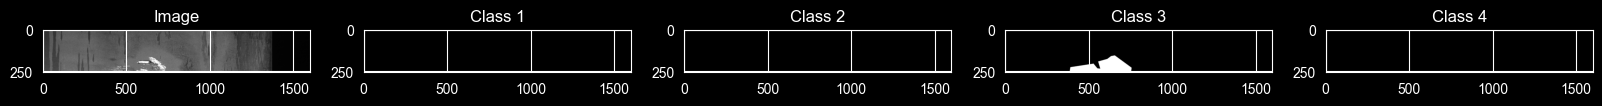

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(20,5))

# ảnh gốc (nếu có)
img = plt.imread("../Dataset/train_images/0a37f0a29.jpg")
axes[0].imshow(img)
axes[0].set_title("Image")

# 4 class mask
for i in range(4):
    axes[i+1].imshow(mask[:,:,i], cmap='gray')
    axes[i+1].set_title(f"Class {i+1}")

plt.show()

In [100]:
df_test.tail(10)

,ImageId,ClassId,EncodedPixels
7085,ff9923932.jpg,3,352770 158 353026 180 353282 192 353538 187 35...
7086,ff9d46e95.jpg,4,326401 4 326658 9 326915 12 327172 13 327429 1...
7087,ffb48ee43.jpg,3,38657 43 38913 128 39169 213 39425 2303 41751 ...
7088,ffbd081d5.jpg,3,280587 11 280841 33 281095 55 281350 76 281604...
7089,ffc9fdf70.jpg,3,306787 4 307025 2 307041 6 307099 4 307280 5 3...
7090,ffcf72ecf.jpg,3,121911 34 122167 101 122422 169 122678 203 122...
7091,fff02e9c5.jpg,3,207523 3 207777 9 208030 15 208283 22 208537 2...
7092,fffe98443.jpg,3,105929 5 106177 14 106424 24 106672 33 106923 ...
7093,ffff4eaa8.jpg,3,16899 7 17155 20 17411 34 17667 47 17923 60 18...
7094,ffffd67df.jpg,3,30931 43 31103 127 31275 211 31489 253 31745 2...


In [111]:
cv2.imshow("Image", mask)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [7]:
class DataPreprocessor:
    """Load data, crop, and prepare data"""

    def __init__(self, csv_path, image_dir, output_dir, patch_size=256, stride=400):
        self.csv_path = csv_path
        self.image_dir = Path(image_dir)
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)

        self.patch_size = patch_size
        self.stride = stride
        self.original_shape = (256, 1600)
        self.patch_shape = (256, 400)

    def load_csv(self):
        """"Load csv file and parse"""
        df = pd.read_csv(self.csv_path)
        df["HasDefect"] = df["EncodedPixels"].notna()
        return df

    # def analyze_data(self, df):
    #     """Analyze dataset statistics"""
    #     print("\n" + "=" * 70)
    #     print("DATA ANALYSIS")
    #     print("=" * 70)
    #
    #     # Class distribution
    #     class_counts = df.groupby('NumDefectClasses')['HasDefect'].sum()
    #     class_names = {1: 'Crazing', 2: 'Inclusion', 3: 'Patches', 4: 'Scratches'}
    #
    #     print("\n Defects per class:")
    #     total_defects = 0
    #     for cls in sorted(df['ClassId'].unique()):
    #         count = class_counts[cls]
    #         name = class_names.get(cls, f"Class {cls}")
    #         pct = (count / len(df[df['ClassId'] == cls])) * 100
    #         print(f"   Class {cls} ({name:12}): {int(count):5} defects ({pct:5.1f}%)")
    #         total_defects += count
    #
    #     # Images statistics
    #     imgs_with_defect = df[df['HasDefect']].groupby('ImageId').size()
    #     imgs_without_defect = df['ImageId'].nunique() - len(imgs_with_defect)
    #
    #     print(f"\n Image statistics:")
    #     print(f"   Total images: {df['ImageId'].nunique()}")
    #     print(f"   With defect: {len(imgs_with_defect)} ({len(imgs_with_defect) / df['ImageId'].nunique() * 100:.1f}%)")
    #     print(f"   Without defect: {imgs_without_defect} ({imgs_without_defect / df['ImageId'].nunique() * 100:.1f}%)")
    #
    #     # Visualize
    #     self._plot_analysis(df, class_names, class_counts)
    #
    #     return class_counts, class_names
    #
    # def _plot_analysis(self, df, class_names, class_counts):
    #     """Plot data analysis"""
    #     fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    #     fig.suptitle('Severstal Dataset Analysis', fontsize=14, fontweight='bold')
    #
    #     # Plot 1: Class distribution
    #     colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
    #     axes[0].bar(range(1, 5), class_counts.values, color=colors, alpha=0.8, edgecolor='black')
    #     axes[0].set_xlabel('Defect Class')
    #     axes[0].set_ylabel('Count')
    #     axes[0].set_title('Defects per Class')
    #     axes[0].set_xticks(range(1, 5))
    #     for i, v in enumerate(class_counts.values):
    #         axes[0].text(i + 1, v, str(int(v)), ha='center', va='bottom', fontweight='bold')
    #     axes[0].grid(axis='y', alpha=0.3)
    #
    #     # Plot 2: Pie chart
    #     wedges, texts, autotexts = axes[1].pie(
    #         class_counts.values,
    #         labels=[f"Class {i}\n({class_names.get(i, f'Class {i}')})" for i in range(1, 5)],
    #         autopct='%1.1f%%',
    #         colors=colors,
    #         startangle=90
    #     )
    #     axes[1].set_title('Class Distribution')
    #     for autotext in autotexts:
    #         autotext.set_color('white')
    #         autotext.set_fontweight('bold')
    #
    #     # Plot 3: Images with/without defects
    #     imgs_with = df[df['HasDefect']].groupby('ImageId').size().shape[0]
    #     imgs_without = df['ImageId'].nunique() - imgs_with
    #     axes[2].bar(['With Defect', 'Without Defect'], [imgs_with, imgs_without],
    #                 color=['#FF6B6B', '#90EE90'], alpha=0.8, edgecolor='black')
    #     axes[2].set_ylabel('Count')
    #     axes[2].set_title('Images with/without Defects')
    #     axes[2].grid(axis='y', alpha=0.3)
    #     for i, v in enumerate([imgs_with, imgs_without]):
    #         axes[2].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')
    #
    #     plt.tight_layout()
    #     plt.savefig(f'./outputs/02_data_analysis.png', dpi=300, bbox_inches='tight')
    #     print(f"\n Analysis plot saved to './outputs/01_data_analysis.png'")
    #     plt.close()

    def create_patches(self, df, save_images=True, save_masks=True):
        new_rows = []
        unique_image = df["ImageId"].unique()

        image_dir = self.output_dir / 'images'
        mask_dir = self.output_dir / 'masks'

        if save_images:
            image_dir.mkdir(parents=True, exist_ok=True)
        if save_masks:
            mask_dir.mkdir(parents=True, exist_ok=True)

        for img_id in tqdm(unique_image, desc="Cropping Images"):
            img_path = self.image_dir / img_id
            if not img_path.exists():
                continue

            image = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            #img_data = df[df["ImageId"]==img_id]
            full_mask = RLEprocessor.build_mask(df, img_id)

            for patch_idx in range(4):
                start_col = patch_idx * self.stride
                enc_col = start_col + self.patch_size

                path_img = image[:, start_col:enc_col].copy()
                patch_id = f"{img_id[:-4]}_patch{patch_idx}.jpg"

                if save_images:
                    patch_path = image_dir / patch_id
                    patch_path.parent.mkdir(parents=True, exist_ok=True)
                    cv2.imwrite(str(patch_path), path_img)

                # Process masks for each class
                patch_mask = full_mask[:, start_col:enc_col, :].copy()

                # Save multi_channel mask
                if save_masks:
                    mask_file = mask_dir / f"{patch_id}_mask.npy"
                    np.save(str(mask_file), patch_mask)

                # Create CSV row
                new_rows.append({
                    'ImageId': f"{patch_id}",
                    'MaskId': f"{patch_id}_mask.npy",
                    'HasDefect': patch_mask.max() > 0,
                    'NumDefectClasses': (patch_mask.max(axis=(0, 1)) > 0).sum()
                })
        return pd.DataFrame(new_rows)

In [8]:
csv_path_all = "../Dataset/train.csv"
img_dir = "../Dataset/train_images"
output_dir ="./Processed_data_once"
preprocessor = DataPreprocessor(csv_path_all, img_dir, output_dir)


In [9]:
df = preprocessor.load_csv()

In [10]:
len(df)

7095

In [11]:
df_patches = preprocessor.create_patches(df, save_images=True, save_masks=True)

Cropping Images: 100%|██████████| 6666/6666 [01:00<00:00, 109.81it/s]


In [12]:
df_patches.to_csv("./Dataset/train_patches_one.csv", index=False)

In [13]:
df_patches.head(20)

,ImageId,MaskId,HasDefect,NumDefectClasses
0,0002cc93b_patch0.jpg,0002cc93b_patch0.jpg_mask.npy,True,1
1,0002cc93b_patch1.jpg,0002cc93b_patch1.jpg_mask.npy,False,0
2,0002cc93b_patch2.jpg,0002cc93b_patch2.jpg_mask.npy,False,0
3,0002cc93b_patch3.jpg,0002cc93b_patch3.jpg_mask.npy,False,0
4,0007a71bf_patch0.jpg,0007a71bf_patch0.jpg_mask.npy,True,1
5,0007a71bf_patch1.jpg,0007a71bf_patch1.jpg_mask.npy,False,0
6,0007a71bf_patch2.jpg,0007a71bf_patch2.jpg_mask.npy,False,0
7,0007a71bf_patch3.jpg,0007a71bf_patch3.jpg_mask.npy,False,0
8,000a4bcdd_patch0.jpg,000a4bcdd_patch0.jpg_mask.npy,True,1
9,000a4bcdd_patch1.jpg,000a4bcdd_patch1.jpg_mask.npy,True,1


In [14]:
mask = df_patches['MaskId'][13]

In [15]:
mask = np.load("../Processed_data/masks/000f6bf48_patch1.jpg_mask.npy")

In [17]:
mask.max()

np.uint8(1)

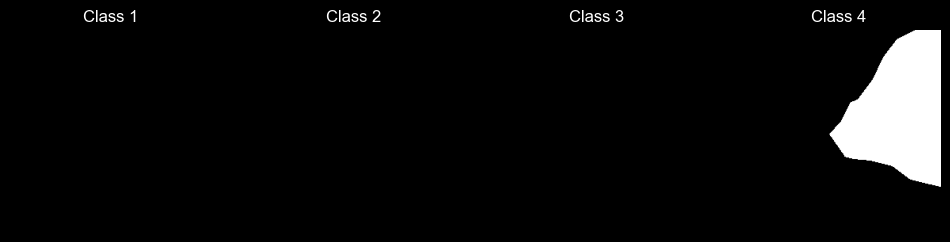

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(mask[:,:,i], cmap='gray')
    plt.title(f"Class {i+1}")
    plt.axis('off')

plt.show()

In [19]:
class SteverstalDataset(Dataset):
    """PyTorch Dataset for Severstal"""

    def __init__(self, df, image_dir, mask_dir, transform=None, num_classes=4):
        self.df = df.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.transform = transform
        self.num_classes = num_classes

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ===== IMAGE =====
        img_path = self.image_dir / row['ImageId']
        image = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

        if image is None:
            raise FileNotFoundError(f"Image not found: {img_path}")

        image = np.expand_dims(image, axis=-1)  # (H, W, 1)

        # ===== MASK =====
        mask_path = self.mask_dir / row['MaskId']
        mask = np.load(str(mask_path))  # (H, W, 4)

        # ===== AUGMENT =====
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
            #print(mask.shape)
            if mask.ndim == 3 and mask.shape[0] != 4:
                mask = mask.permute(2, 0, 1)
        else:
            image = image.astype(np.float32) / 255.0
            image = torch.from_numpy(image).permute(2, 0, 1).float()
            mask = torch.from_numpy(mask).permute(2, 0, 1).float()

        return {
            'image': image,   # (1, H, W)
            'mask': mask,     # (4, H, W)
            'image_id': row['ImageId']
        }

### Augmentation Data

In [20]:
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    # Focus defect
    A.CropNonEmptyMaskIfExists(256, 256, p=0.7),

    # Geometric
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),

    # Image quality
    A.CLAHE(p=0.3),
    A.GaussianBlur(p=0.2),

    # Resize cho model
    A.Resize(224, 224),

    # Normalize grayscale
    A.Normalize(mean=(0.5,), std=(0.5,)),

    # Convert to tensor
    ToTensorV2()
])
val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
])

In [21]:
path_patches = '../Dataset/train_patches_one.csv'
df_patches = pd.read_csv(path_patches)

In [22]:
train_df, val_df = train_test_split(df_patches, test_size=0.2, random_state=42)

In [23]:
print(len(train_df))
print(len(val_df))


21331
5333


In [24]:
train_dataset = SteverstalDataset(
            train_df,
            image_dir="./Processed_data_once/images",
            mask_dir="./Processed_data_once/masks",
            transform=train_transform,
            num_classes=4)
val_dataset = SteverstalDataset(
            val_df,
            image_dir="./Processed_data_once/images",
            mask_dir="./Processed_data_once/masks",
            transform=val_transform,
            num_classes=4)

In [25]:
sample = train_dataset[0]
print(sample['image'].shape)
print(sample['mask'].shape)

torch.Size([1, 224, 224])
torch.Size([4, 224, 224])


In [26]:
len(train_dataset)

21331

In [27]:
len(val_dataset)

5333

### Dataloader

In [28]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)

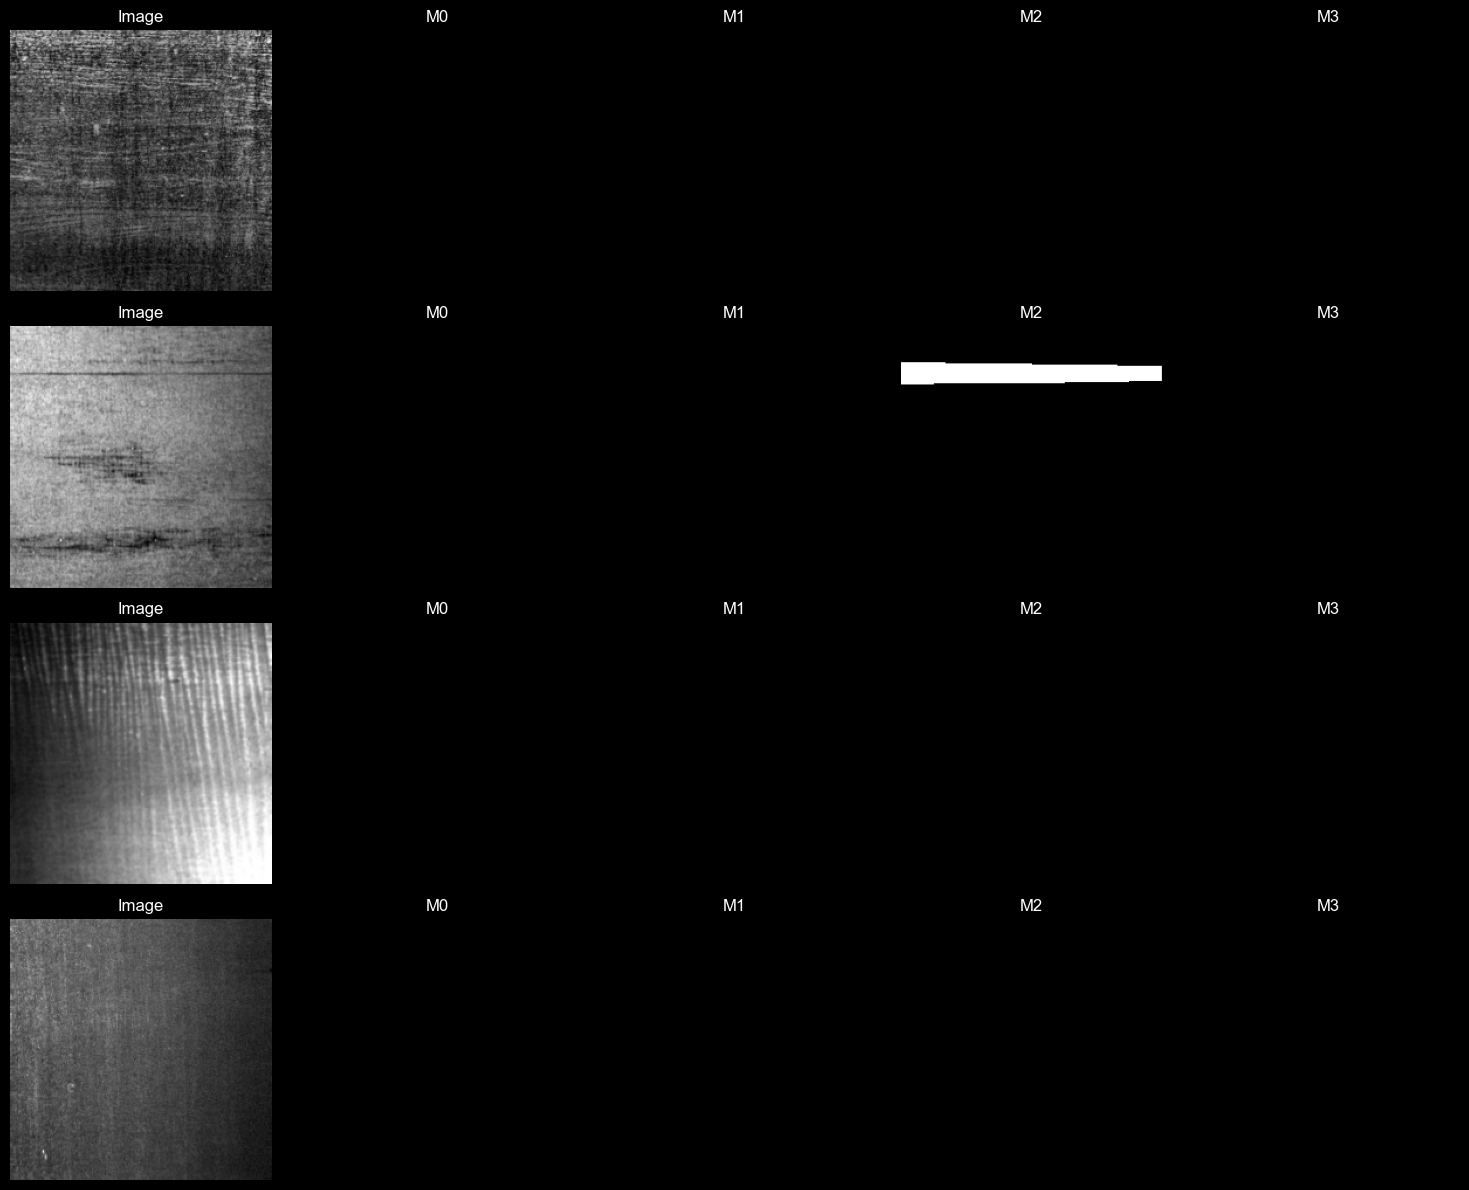

In [29]:
batch = next(iter(train_loader))
images = batch['image']
masks = batch['mask']
B = images.shape[0]  # batch size
num_show = min(4, B)  # hiển thị tối đa 4 sample

plt.figure(figsize=(15, 3 * num_show))

for i in range(num_show):
    img = images[i].cpu().numpy()[0]   # (H, W)
    mask = masks[i].cpu().numpy()      # (4, H, W)
    #print(mask[i])

    # unnormalize nếu cần
    img = (img * 0.5) + 0.5

    # ===== Image =====
    plt.subplot(num_show, 5, i*5 + 1)
    plt.imshow(img, cmap='gray')
    plt.title("Image")
    plt.axis('off')

    # ===== 4 Masks =====
    for j in range(4):
        plt.subplot(num_show, 5, i*5 + 2 + j)
        plt.imshow(mask[j,:,:], cmap='gray')
        plt.title(f"M{j}")
        plt.axis('off')

plt.tight_layout()
plt.show()

### Test

In [ ]:
import pandas as pd

customers = pd.DataFrame({
    "customer_id": [1,2,3,4,5,6,7,8,9,10],
    "name": [
        "An","Binh","Chi","Dung","Huy",
        "Khanh","Lan","Minh","Nam","Phuong"
    ]
})

print(customers)

In [ ]:
orders = pd.DataFrame({
    "order_id":[101,102,103,104,105,106,107,108,109,110,111,112],
    "customer_id":[1,2,1,3,2,5,5,5,7,8,1,9],
    "product":[
        "Laptop","Phone","Mouse","Keyboard",
        "Tablet","Monitor","Mouse","Keyboard",
        "Laptop","Camera","Headphone","Phone"
    ]
})

print(orders)

In [ ]:
df = pd.merge(orders, customers, on="customer_id")

print(df)

In [ ]:
df.loc[(df['name'] == 'An') & (df['customer_id']==1), "customer_id"].values[0]

In [ ]:
cv2.imshow("Image", image)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
arr = [16, 3, 25, 5, 32, 7]



In [ ]:
print(start, length)

In [ ]:
for st, le in zip(start, length):
    print(st, le)

In [ ]:
image = np.zeros(10*5, dtype=np.uint8)
for st, le in zip(start, length):
    image[st:st + le] = 1
print(image)

In [ ]:
# def rle2mask(rle_list, height, width):
#     # Khởi tạo ma trận toàn số 0
#
#     mask = np.zeros(width * height, dtype=np.uint8)
#
#     # Giải mã rle_list: [start1, length1, start2, length2, ...]
#     for i in range(0, len(rle_list), 2):
#         start = rle_list[i] - 1  # RLE thường 1-based
#         length = rle_list[i+1]
#         mask[start : start + length] = 1
#
#     return mask.reshape((height, width))
#
# # Ví dụ
# rle = [2, 1, 8, 2] # Ví dụ: mask 1 từ vị trí 2, dài 3; mask 1 từ vị trí 7, dài 2
# mask = rle2mask(rle, 3, 3)
# print(mask)


In [ ]:
mask = np.array(mask)

In [ ]:
mask.shape

In [ ]:
image = cv2.imread("../Timeline.png", 1)

In [ ]:
cv2.imshow("Image", mask)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
0PATH = "../Dataset"
for filename in os.listdir(PATH):
    print(os.path.join(PATH, filename))

In [ ]:
csv_Path = "../Dataset/train.csv"

In [ ]:
data = pd.read_csv(csv_Path)

In [ ]:
data.head(5)

In [ ]:
image = data["EncodedPixels"][0]

In [ ]:
image = [i for i in image]

In [ ]:
type(image)

In [ ]:
image = rle2mask(image, 256, 1600)

## Model

### Function Blocks

In [133]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=kernel_size, padding=padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.conv_block(x)

class Encoder(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.MaxPool2d(kernel_size=2),
            ConvBlock(in_channels, out_channels, kernel_size, padding),
        )
    def forward(self, x):
        return self.encoder(x)

class Decoder(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding, bilinear=True):
        super().__init__()
        if bilinear:
            self.conv_trans = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv_block = ConvBlock(in_channels, out_channels, kernel_size, padding)
        else:
            self.conv_trans = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
            self.conv_block = ConvBlock(in_channels, out_channels, kernel_size, padding)

    def forward(self, x1, x2):
        # B, C, H, W
        x1= self.conv_trans(x1)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, (diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2))
        x = torch.cat([x2, x1], dim=1) # concat by channel
        return self.conv_block(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)

    def forward(self, x):
        return self.conv(x)


### Model unet

In [137]:
class UNet(nn.Module):
    def __init__(self, n_channels, n_classes, bilinear=False):
        super().__init__()
        self.inc = ConvBlock(n_channels, 64, kernel_size=3, padding=1)
        self.down1 = Encoder(64, 128, 3, 1)
        self.down2 = Encoder(128, 256, 3, 1)
        self.down3 = Encoder(256, 512, 3, 1)
        factor = 2 if bilinear else 1
        self.down4 = Encoder(512, 1024 // factor, 3, 1)
        self.bottom_neck = ConvBlock(1024//factor, 1024//factor, kernel_size=1, padding=0)
        self.up1 = Decoder(1024, 512//factor, 3, 1, bilinear=bilinear)
        self.up2 = Decoder(512, 256//factor, 3, 1, bilinear=bilinear)
        self.up3 = Decoder(256, 128//factor, 3, 1, bilinear=bilinear)
        self.up4 = Decoder(128, 64, 3, 1, bilinear=bilinear)
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        x1 = self.inc(x) # 64
        x2 = self.down1(x1) # 128
        x3 = self.down2(x2) # 256
        x4 = self.down3(x3) #512
        x5 = self.down4(x4) # 1024
        x5 = self.bottom_neck(x5) # 1024
        x = self.up1(x5, x4) # 512
        x = self.up2(x, x3) # 256
        x = self.up3(x, x2) # 128
        logits = self.up4(x, x1) # 64
        return self.outc(logits)

In [138]:
tensor1 = torch.randn([1, 3, 224, 224]) # batch, channel, W, H


In [139]:
model = UNet(n_channels=3, n_classes=4, bilinear=False)

In [140]:
output = model(tensor1)

In [141]:
output.shape

torch.Size([1, 4, 224, 224])

## Metrics

In [152]:
class Dice_loss(nn.Module):
    def __init__(self, smooth):
        super(Dice_loss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        # Convert logits to probabilities
        probs = torch.sigmoid(logits)

        # Flatten tensors
        probs = probs.view(-1)
        targets = targets.view(-1)

        # Calculate intersection and union
        intersection = (probs * targets).sum()
        dice = (2. * intersection + self.smooth) / (probs.sum() + targets.sum() + self.smooth)

        return 1 - dice.mean()

In [153]:
class BCE_DiceLoss(nn.Module):
    def __init__(self, bce_weight, dice_weight, smooth):
        super().__init__()
        self.smooth = smooth
        self.bce_loss = nn.BCEWithLogitsLoss()
        self.dice_loss = Dice_loss(smooth=self.smooth)
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight


    def forward(self, logits, targets):
        bce_loss = self.bce_loss(logits, targets)
        dice_loss = self.dice_loss(logits, targets)
        return self.bce_weight * bce_loss + self.dice_weight * dice_loss

In [ ]:
print(os.listdir())

In [167]:
CONFIG = {
    'original_data': './Dataset',
    'train_images': './Dataset/train_images',
    'test_images': './Dataset/test_images',
    'output_dir': './processed_data',
    'image_loader': './processed_data/images',
    'mask_loader': './processed_data/masks',

    'test_size': 0.2,
    'epochs_max': 100,
    'n_classes': 4,
    'learning_rate': 0.001,
    'smooth': 1e-3,
    'bce_weight': 0.6,
    'dice_weight': 0.4,
    'n_channels': 1,

    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu')
}

optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'])
criterion = BCE_DiceLoss(smooth=CONFIG['smooth'], bce_weight=CONFIG['bce_weight'], dice_weight=CONFIG['dice_weight'])
model = UNet(n_channels=CONFIG['n_channels'], n_classes=CONFIG['n_classes'], bilinear=False)

## Evaluation

In [168]:
def evaluate(model, val_loader, criterion, device):
    model.eval()
    test_loss = 0.0
    dice_loss = 0.0
    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(device)
            targets = targets.to(device)
            logits = model(images)
            loss = criterion(logits, targets)
            test_loss += loss.item()
            dice = Dice_loss(smooth=CONFIG['smooth'])(logits, targets)
            dice_loss += dice.item()
    test_loss /= len(val_loader)
    dice_loss /= len(val_loader)
    return test_loss, dice_loss


## Training

In [169]:
def train(model, train_loader, val_loader, optimizer, criterion, device, CONFIG):
    Epochs = CONFIG['epochs_max']
    model.to(device)

    train_losses = []
    val_losses = []
    dice_scores = []

    for epoch in range(Epochs):
        model.train()
        running_loss = 0.0

        loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{Epochs}]")

        for images, targets in loop:
            images = images.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, targets)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            loop.set_postfix(loss=loss.item())

        epoch_loss = running_loss / len(train_loader)

        # validation
        val_loss_epoch, dice_epoch = evaluate(model, val_loader, criterion, device)

        train_losses.append(epoch_loss)
        val_losses.append(val_loss_epoch)
        dice_scores.append(dice_epoch)

        print(f"Epoch: [{epoch+1}/{Epochs}] | "
              f"Train Loss: {epoch_loss:.4f} | "
              f"Val Loss: {val_loss_epoch:.4f} | "
              f"Dice: {dice_epoch:.4f}")

    return train_losses, val_losses, dice_scores

In [170]:
def train(model, train_loader, val_loader, optimizer, criterion, device):
    Epochs = CONFIG['epochs_max']
    model.to(device)

    train_losses = []
    val_losses = []
    dice_scores = []

    # 🔥 Scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',       # giảm theo val_loss
        patience=3,
        factor=0.5,
        verbose=True
    )

    best_dice = 0.0

    for epoch in range(Epochs):
        model.train()
        running_loss = 0.0

        loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{Epochs}]")

        for images, targets in loop:
            images = images.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()

            logits = model(images)
            loss = criterion(logits, targets)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            loop.set_postfix(loss=loss.item())

        epoch_loss = running_loss / len(train_loader)

        # VALIDATION
        val_loss_epoch, dice_epoch = evaluate(model, val_loader, criterion, device)

        train_losses.append(epoch_loss)
        val_losses.append(val_loss_epoch)
        dice_scores.append(dice_epoch)

        # Scheduler update
        scheduler.step(val_loss_epoch)

        # Save best model theo Dice
        if dice_epoch > best_dice:
            best_dice = dice_epoch
            torch.save(model.state_dict(), "best_model.pth")
            print(f"✅ Saved best model (Dice: {best_dice:.4f})")

        print(f"Epoch [{epoch+1}/{Epochs}] | "
              f"Train Loss: {epoch_loss:.4f} | "
              f"Val Loss: {val_loss_epoch:.4f} | "
              f"Dice: {dice_epoch:.4f}")

    return train_losses, val_losses, dice_scores